✓ COVID: Image trouvée - COVID\images\COVID-1.png
✓ NORMAL: Image trouvée - NORMAL\images\Normal-1.png
✓ Viral Pneumonia: Image trouvée - Viral Pneumonia\images\Viral Pneumonia-1.png
✓ Lung_Opacity: Image trouvée - Lung_Opacity\images\Lung_Opacity-1.png


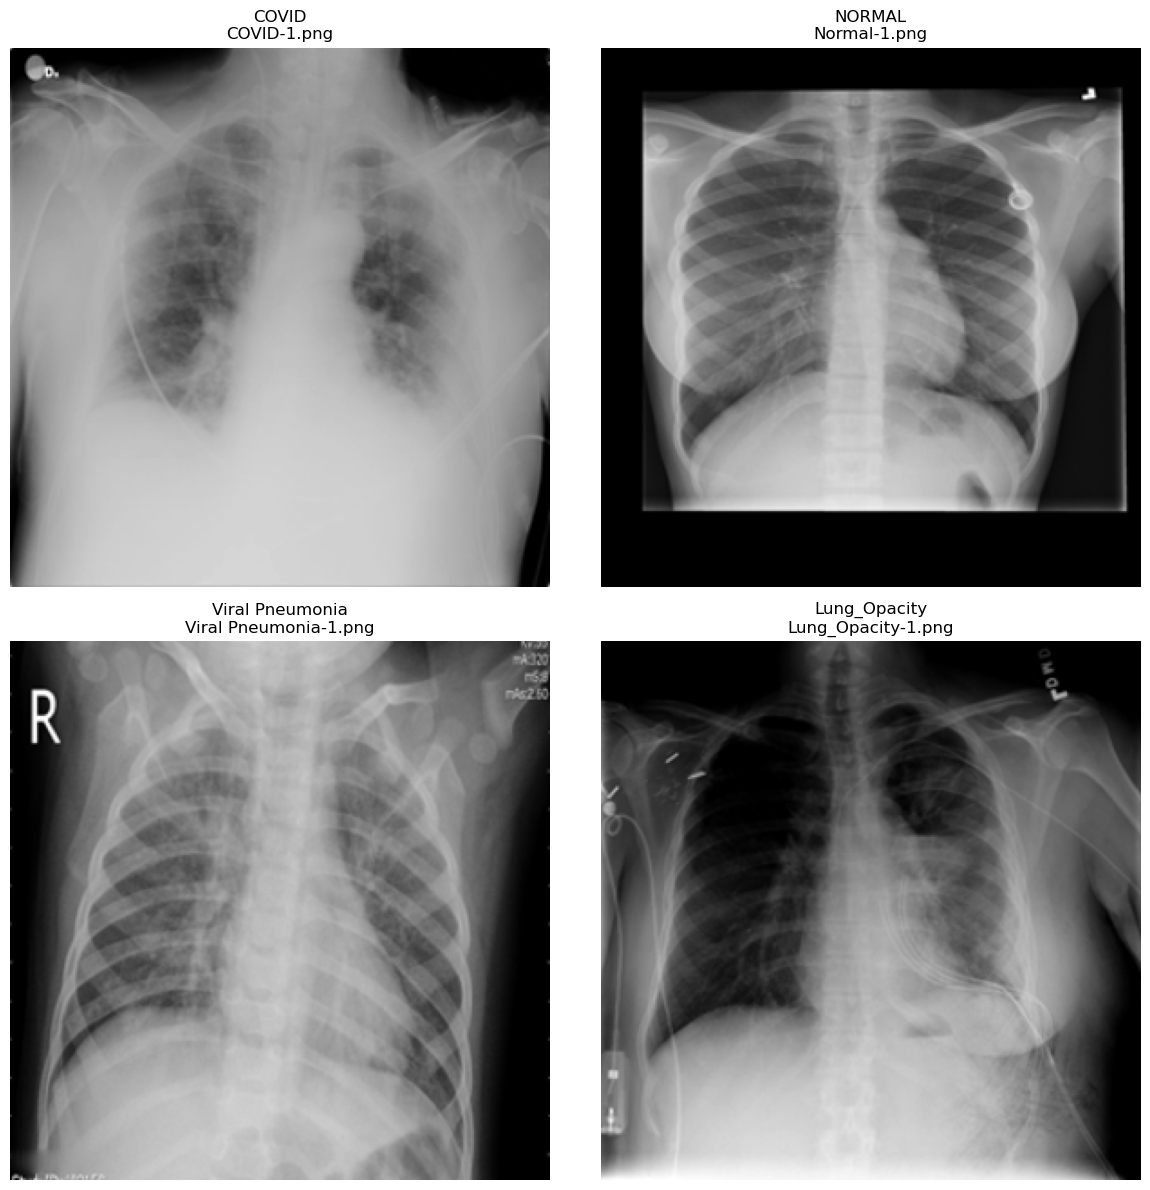

In [6]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import glob

# Chemin dataset
data_dir = r"C:\Users\MSI\Desktop\COVID19-XRay-Classification\data"

classes = ["COVID", "NORMAL", "Viral Pneumonia", "Lung_Opacity"]

# Fonction pour trouver les images (supportant les sous-dossiers)
def get_first_image(class_folder):
    # Chercher dans tous les sous-dossiers
    image_patterns = [
        os.path.join(class_folder, "*.png"),
        os.path.join(class_folder, "*.jpg"),
        os.path.join(class_folder, "*.jpeg"),
        os.path.join(class_folder, "**/*.png"), 
        os.path.join(class_folder, "**/*.jpg"),
        os.path.join(class_folder, "**/*.jpeg")
    ]
    
    for pattern in image_patterns:
        images = glob.glob(pattern, recursive=True)
        if images:
            return images[0]
    return None

# Visualisation
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

for i, c in enumerate(classes):
    class_path = os.path.join(data_dir, c)
    
    if os.path.exists(class_path):
        # Trouver une image
        img_path = get_first_image(class_path)
        
        if img_path:
            try:
                img = Image.open(img_path)
                axs[i//2, i%2].imshow(img, cmap='gray')
                axs[i//2, i%2].set_title(f"{c}\n{os.path.basename(img_path)}")
                axs[i//2, i%2].axis('off')
                print(f"✓ {c}: Image trouvée - {os.path.relpath(img_path, data_dir)}")
            except Exception as e:
                axs[i//2, i%2].text(0.5, 0.5, f"Erreur\nimage", 
                                   ha='center', va='center', color='red')
                axs[i//2, i%2].set_title(c)
                axs[i//2, i%2].axis('off')
                print(f"✗ {c}: Erreur - {e}")
        else:
            axs[i//2, i%2].text(0.5, 0.5, "Aucune\nimage", 
                               ha='center', va='center')
            axs[i//2, i%2].set_title(c)
            axs[i//2, i%2].axis('off')
            print(f"✗ {c}: Aucune image trouvée")
    else:
        axs[i//2, i%2].text(0.5, 0.5, "Dossier\nnon trouvé", 
                           ha='center', va='center', color='red')
        axs[i//2, i%2].set_title(c)
        axs[i//2, i%2].axis('off')
        print(f"✗ {c}: Dossier non trouvé")

plt.tight_layout()
plt.show()